In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import yfinance as yf


In [ ]:

meta = yf.Ticker("VNM")

data = meta.history(period="20y")
# meta.info.
# data
# data.to_csv('VNM.csv')

{'phone': '888-658-8287',
 'longBusinessSummary': "The fund normally invests at least 80% of its total assets in securities that comprise the fund's benchmark index. The index includes securities of Vietnamese companies. A company is generally considered to be a Vietnamese company if it is incorporated in Vietnam. It is non-diversified.",
 'companyOfficers': [],
 'executiveTeam': [],
 'maxAge': 86400,
 'priceHint': 2,
 'previousClose': 12.6,
 'open': 12.51,
 'dayLow': 12.47,
 'dayHigh': 12.59,
 'regularMarketPreviousClose': 12.6,
 'regularMarketOpen': 12.51,
 'regularMarketDayLow': 12.47,
 'regularMarketDayHigh': 12.59,
 'trailingPE': 14.925787,
 'volume': 869957,
 'regularMarketVolume': 869957,
 'averageVolume': 1212186,
 'averageVolume10days': 518150,
 'averageDailyVolume10Day': 518150,
 'bid': 12.44,
 'ask': 12.6,
 'bidSize': 11,
 'askSize': 13,
 'yield': 0.0,
 'totalAssets': 368815776,
 'fiftyTwoWeekLow': 10.1,
 'fiftyTwoWeekHigh': 13.0,
 'fiftyDayAverage': 12.1096,
 'twoHundredDay

: 

In [10]:
df = pd.read_csv('VML.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2009-08-14 00:00:00-04:00,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0
1,2009-08-17 00:00:00-04:00,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0
2,2009-08-18 00:00:00-04:00,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0
3,2009-08-19 00:00:00-04:00,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0
4,2009-08-20 00:00:00-04:00,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0


In [11]:
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.strftime('%Y-%m-%d')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2009-08-14,20.685430,20.708432,19.673393,19.949404,0,0.0,0.0,0.0
1,2009-08-17,19.972403,22.594500,19.320714,19.343714,0,0.0,0.0,0.0
2,2009-08-18,20.693101,20.693101,19.566060,19.742399,0,0.0,0.0,0.0
3,2009-08-19,19.803731,20.118076,19.604390,20.033739,0,0.0,0.0,0.0
4,2009-08-20,20.248414,20.953774,20.240747,20.677763,0,0.0,0.0,0.0


In [12]:
df = df[['Date', 'Close']]

In [83]:
df = df.set_index(['Date'])
df.head()

,Close
Date,
2009-08-14,19.949404
2009-08-17,19.343714
2009-08-18,19.742399
2009-08-19,20.033739
2009-08-20,20.677763


<Axes: >

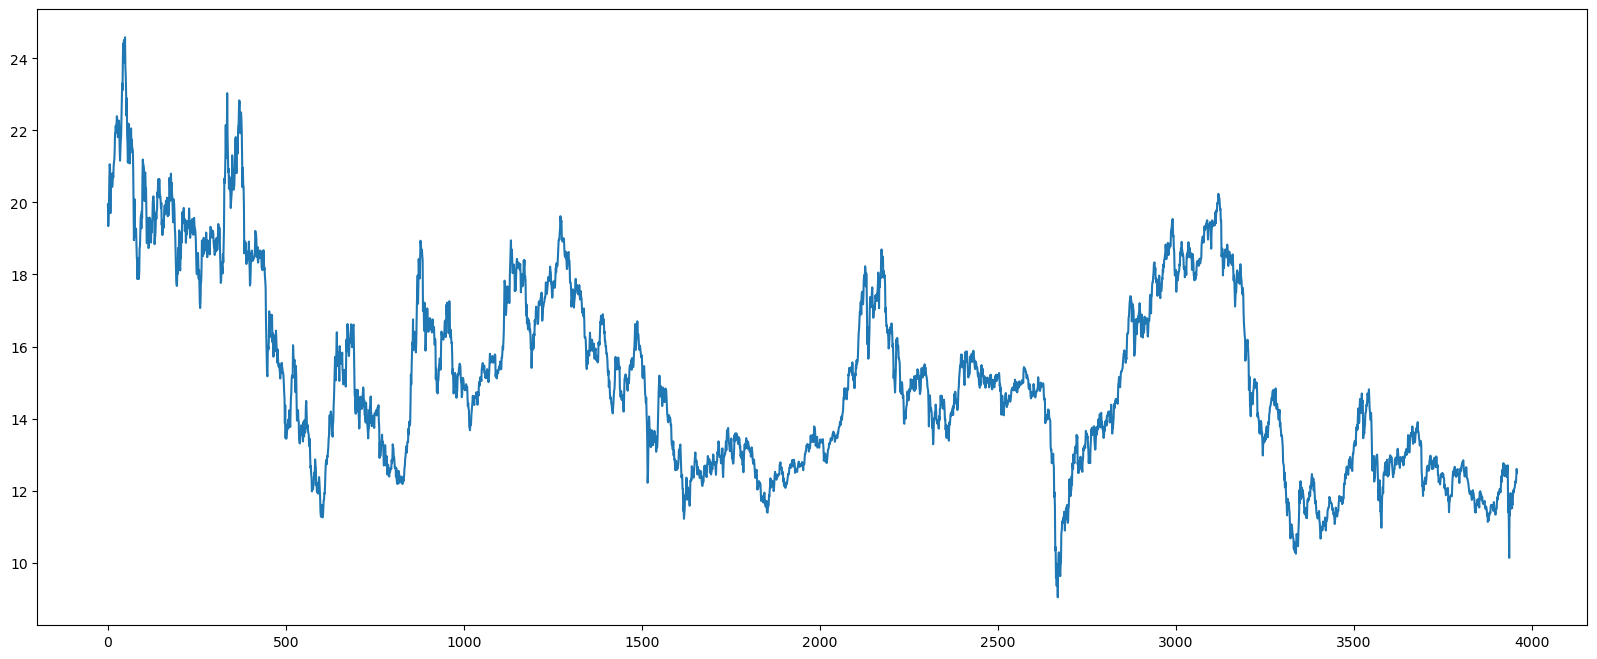

In [13]:
plt.rcParams['figure.figsize'] = (20, 8)
df['Close'].plot()

In [34]:
## 1 AR : 3 ngay du doan 1 ngay
def getXy(data, window_size = 3):
    n = len(data) - window_size
    dic = {}
    for i in range(window_size):
        dic[f'X{i}'] = data[i : n + i]
    
    df = pd.DataFrame(data = dic)
    df['y'] = data[window_size:]
    return df

In [49]:
scaler = MinMaxScaler()
df['CloseScale'] = scaler.fit_transform(df[['Close']])

In [50]:
window_size = 3
df_data = getXy(df['CloseScale'].values, window_size)
#X.shape, y.shape
df_data

,X0,X1,X2,y
0,0.701740,0.662793,0.688429,0.707163
1,0.662793,0.688429,0.707163,0.748574
2,0.688429,0.707163,0.748574,0.773223
3,0.707163,0.748574,0.773223,0.763857
4,0.748574,0.773223,0.763857,0.685964
...,...,...,...,...
3951,0.195087,0.197659,0.206018,0.207947
3952,0.197659,0.206018,0.207947,0.204732
3953,0.206018,0.207947,0.204732,0.217592
3954,0.207947,0.204732,0.217592,0.229166


In [51]:
X = df_data.drop(columns = 'y').values
y = df_data['y'].values

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)
# X_train[:3,]

In [53]:
# ! pip install tensorflow


In [58]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Dropout

In [59]:
# Build RNN model
model = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(100, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32, verbose=1)
model.summary()

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0263 - val_loss: 2.9484e-04
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 2.3713e-04
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - val_loss: 2.0197e-04
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6545e-04 - val_loss: 2.2018e-04
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0876e-04 - val_loss: 2.2364e-04
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.2796e-04 - val_loss: 1.6975e-04
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3289e-04 - val_loss: 2.3139e-04
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9692e-04 - val_loss: 1.8504e-04
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1332e-04 - val_loss: 1.8691e-04
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2019e-04 - val_loss: 2.0389e-04
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9638e-04

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 3, 100)         │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,405 (208.62 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,604 (139.08 KB)

In [56]:
model.evaluate(X_train, y_train), model.evaluate(X_test, y_test)

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.0954e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0963e-04 


(0.0002645909262355417, 0.0001670806377660483)

In [60]:
# Predict
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [61]:
r2_score(y_test, y_test_pred), r2_score(y_train, y_train_pred)

(0.796409813189818, 0.9896814837046998)

In [68]:
y_test_pred.shape

(198, 1)

In [70]:
y_train_pred_inv = scaler.inverse_transform(y_train_pred).flatten()
y_test_pred_inv = scaler.inverse_transform(y_test_pred).flatten()

df['PredictRNN'] = np.concat(([np.nan] * window_size, y_train_pred_inv, y_test_pred_inv))

df.head()

,Date,Close,PredictArima,PredictSArima,CloseScale,PredictRNN
0,2009-08-14,19.949404,19.930532,19.949404,0.701740,NaN
1,2009-08-17,19.343714,19.336286,19.343714,0.662793,NaN
2,2009-08-18,19.742399,19.722210,19.742399,0.688429,NaN
3,2009-08-19,20.033739,20.007312,30.008441,0.707163,19.528017
4,2009-08-20,20.677763,20.646704,20.072073,0.748574,19.795708


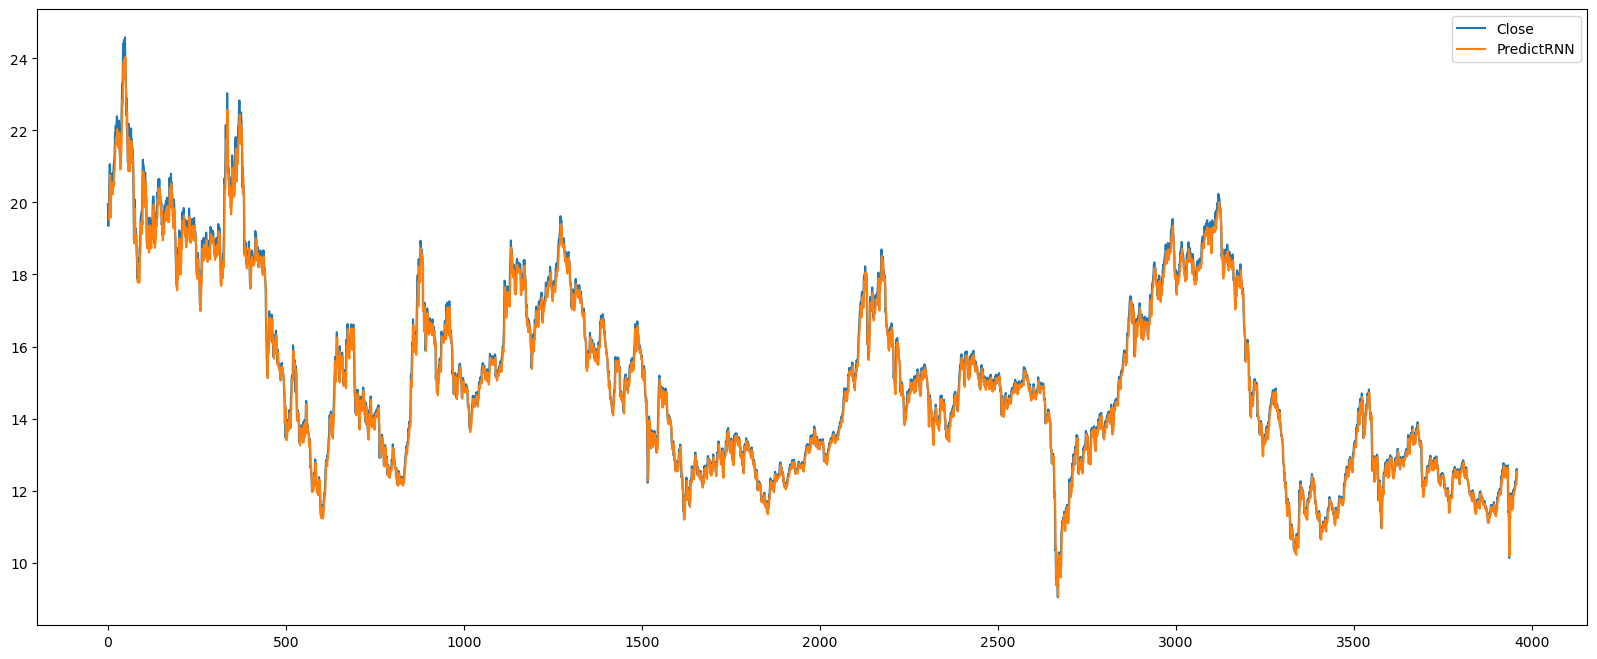

In [73]:
df['Close'].plot()
df['PredictRNN'].plot()

plt.legend(['Close', 'PredictRNN'])
plt.show()

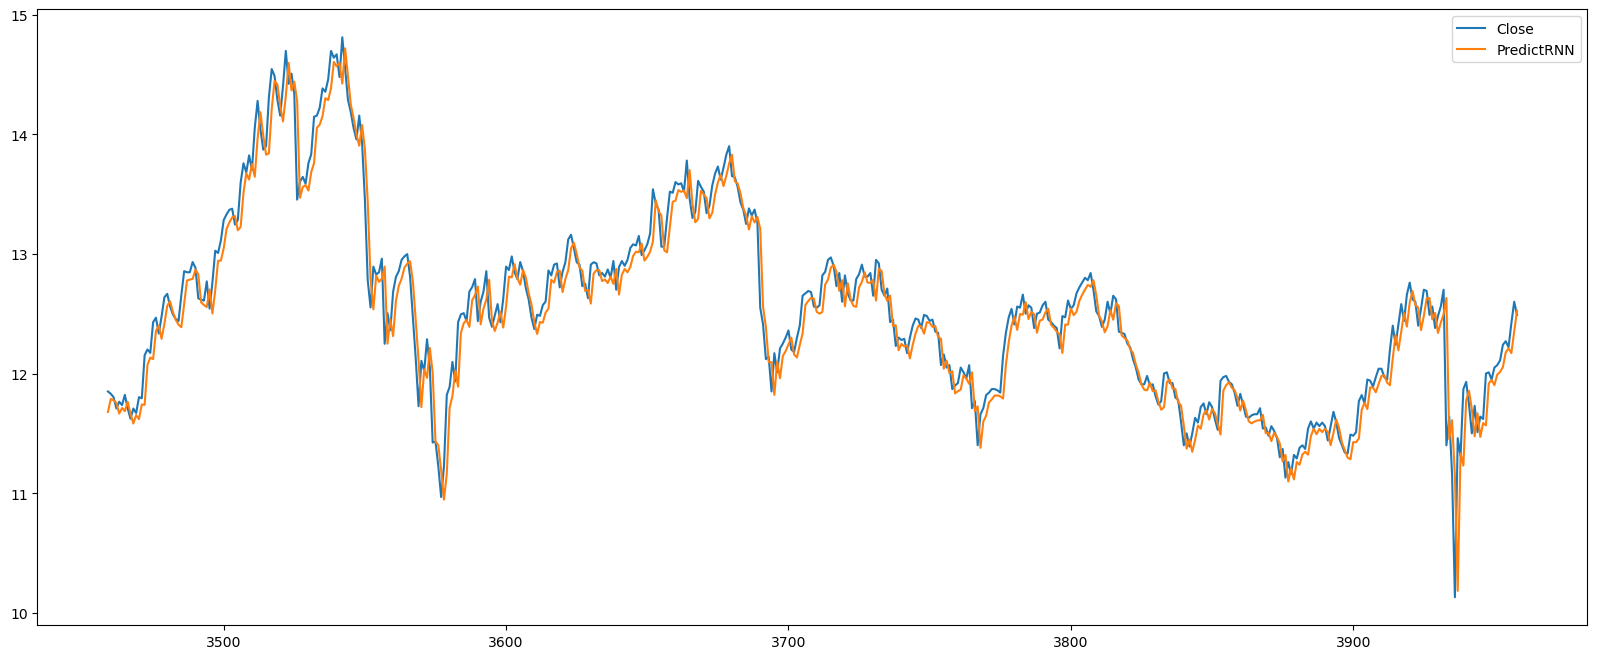

In [72]:
df.iloc[-500:]['Close'].plot()
df.iloc[-500:]['PredictRNN'].plot()

plt.legend(['Close', 'PredictRNN'])
plt.show()

In [58]:
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.9995212531460896, 0.9811548163811101)

In [59]:
y_train_predict = lg.predict(X_train)
y_test_predict = lg.predict(X_test)

In [60]:
df.head()

,Close
Date,
1985-05-10,0.069538
1985-05-13,0.068679
1985-05-14,0.067821
1985-05-15,0.068679
1985-05-16,0.073401


In [61]:
# [np.nan] * window_size, y_train_predict, y_test_predict

df['PredictAutoRegression'] = np.concat(([np.nan] * window_size, y_train_predict, y_test_predict))

df.head()

,Close,PredictAutoRegression
Date,,
1985-05-10,0.069538,NaN
1985-05-13,0.068679,NaN
1985-05-14,0.067821,NaN
1985-05-15,0.068679,0.074619
1985-05-16,0.073401,0.075384


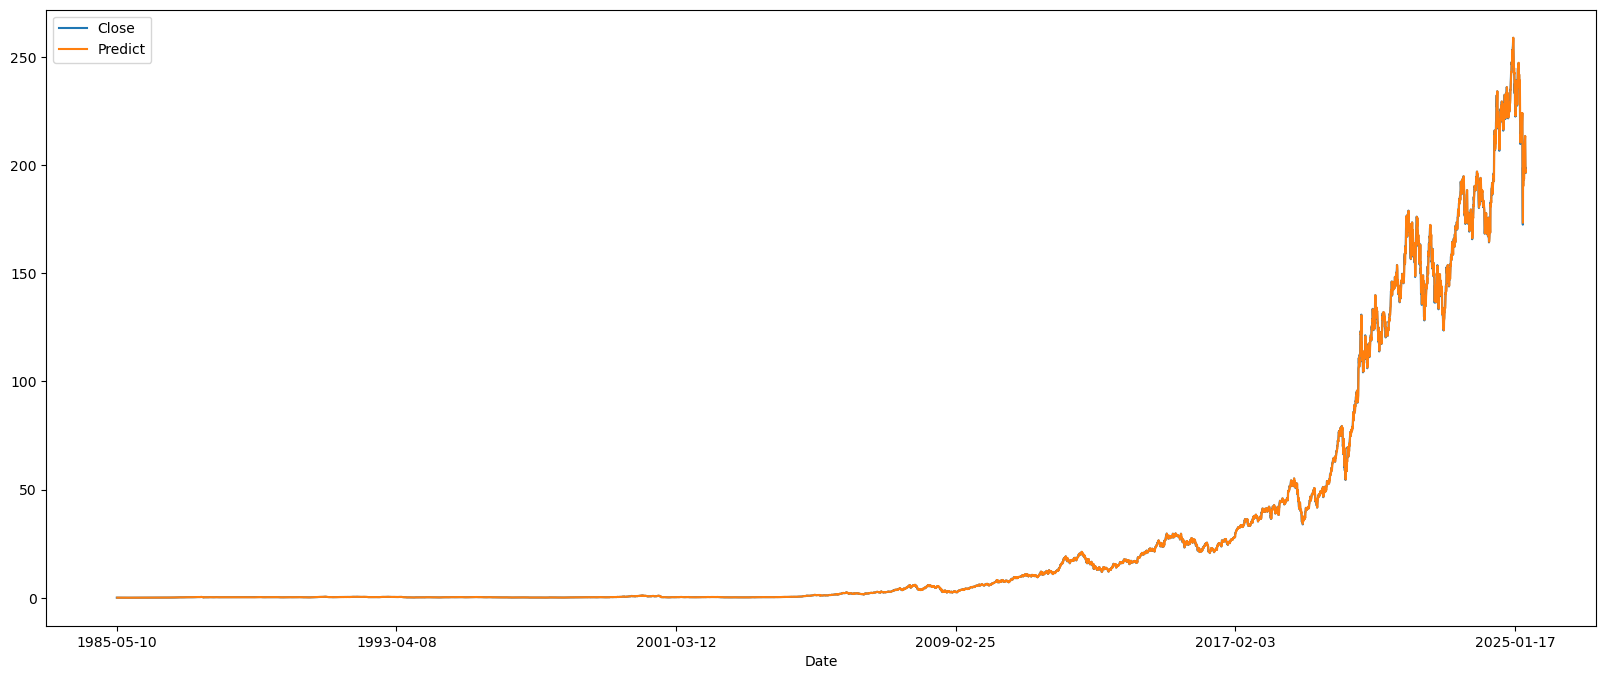

In [62]:
df['Close'].plot()
df['PredictAutoRegression'].plot()

plt.legend(['Close', 'Predict'])
plt.show()

In [30]:
def forcast(data, k = 1, window_size = 3):
    X = data[-window_size:]
    for i in range(k):
        
        y = lg.predict([X])
        print(X, y)
        X = np.concat((X[1:], y))
    return y


In [31]:
forcast(df['Close'].values, k = 3)

NameError: name 'lg' is not defined

In [65]:
## 2 Random Forest
forest = RandomForestRegressor()
forest.fit(X_train, y_train)
forest.score(X_train, y_train), forest.score(X_test, y_test)

(0.9999174319349318, -1.2453377270539678)

In [66]:
y_train_predict = forest.predict(X_train)
y_test_predict = forest.predict(X_test)

In [67]:
df['PredictForest'] = np.concat(([np.nan] * window_size, y_train_predict, y_test_predict))

df.head()

,Close,PredictAutoRegression,PredictForest
Date,,,
1985-05-10,0.069538,NaN,NaN
1985-05-13,0.068679,NaN,NaN
1985-05-14,0.067821,NaN,NaN
1985-05-15,0.068679,0.074619,0.067902
1985-05-16,0.073401,0.075384,0.071632


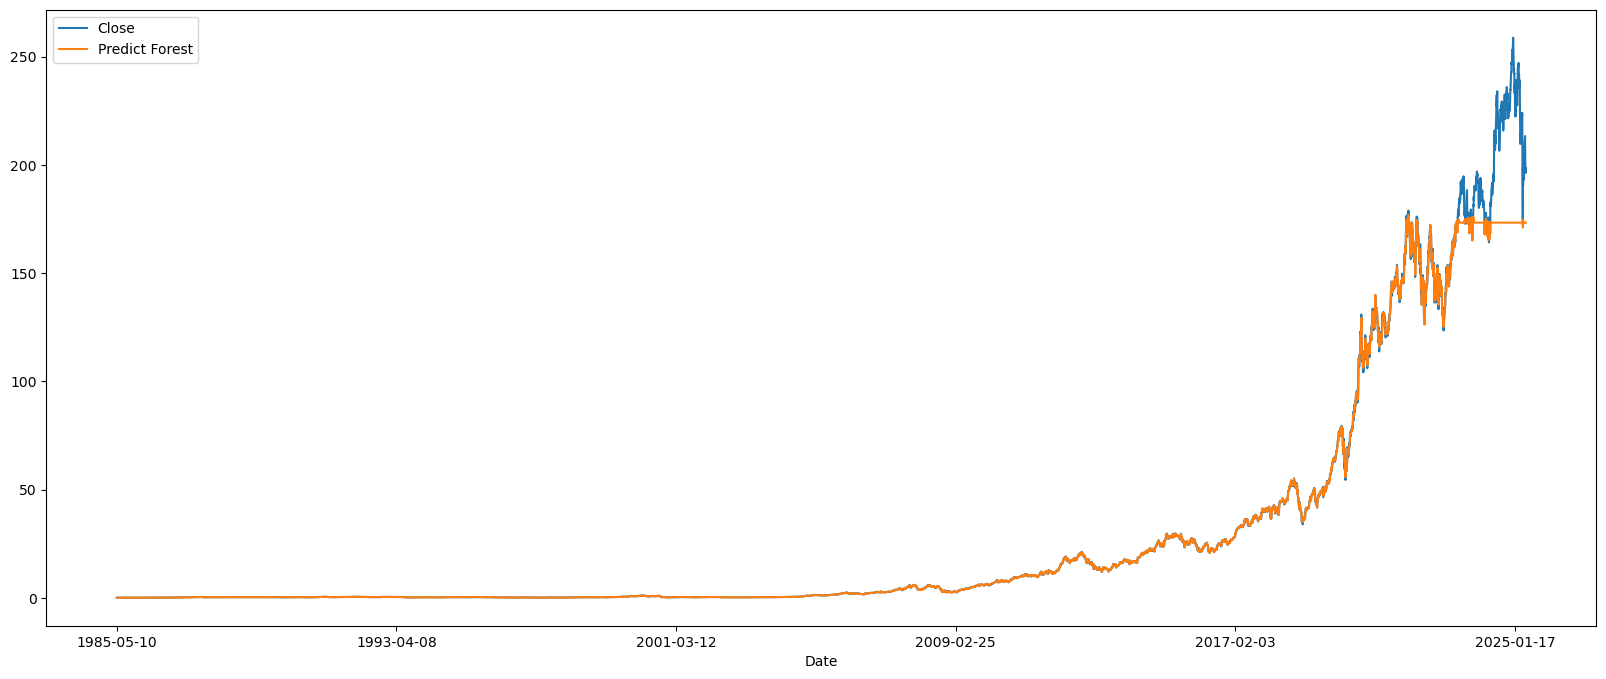

In [68]:
df['Close'].plot()
df['PredictForest'].plot()

plt.legend(['Close', 'Predict Forest'])
plt.show()

In [69]:
df.head()

,Close,PredictAutoRegression,PredictForest
Date,,,
1985-05-10,0.069538,NaN,NaN
1985-05-13,0.068679,NaN,NaN
1985-05-14,0.067821,NaN,NaN
1985-05-15,0.068679,0.074619,0.067902
1985-05-16,0.073401,0.075384,0.071632


In [85]:
minMax = MinMaxScaler()
df['CloseScaled']  = minMax.fit_transform(df[['Close']])
df.head()

,Close,CloseScaled
Date,,
2009-08-14,19.949404,0.701740
2009-08-17,19.343714,0.662793
2009-08-18,19.742399,0.688429
2009-08-19,20.033739,0.707163
2009-08-20,20.677763,0.748574


In [14]:
## 3 ARIMA
window_size = 3
X_arima = df['Close'].values
X_arima_train, X_arima_test = train_test_split(X_arima, test_size=0.1, shuffle=False)

# Fit ARIMA(p=1, d=2, q=1) (AR, I, AM)
print("\nFit mô hình ARIMA(3,0,0)...")
model = sm.tsa.ARIMA(X_arima_train, order=(window_size, 0, 1))
result = model.fit()

print("\nSummary của mô hình:")
print(result.summary())


Fit mô hình ARIMA(3,0,0)...

Summary của mô hình:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3563
Model:                 ARIMA(3, 0, 1)   Log Likelihood                 -95.976
Date:                Sun, 11 May 2025   AIC                            203.953
Time:                        16:31:50   BIC                            241.023
Sample:                             0   HQIC                           217.171
                               - 3563                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.4170      0.970     15.896      0.000      13.516      17.318
ar.L1          0.5995      1.773      0.338      0.735      -2.876       4.075
a

In [15]:
#pred = result.predict(start=X_arima_train.shape[0] + 1, end=X_arima_train.shape[0] + X_arima_test.shape[0])
pred = result.predict(start=1, end=X_arima.shape[0])

pred.shape, X_arima_train.shape, X_arima_test.shape
# Align actual values

# Calculate R²
# r2 = r2_score(X_arima_test, pred)
# print(f'R² score: {r2:.4f}')

((3959,), (3563,), (396,))

In [16]:
df['PredictArima'] = pred
df.head()

,Date,Close,PredictArima
0,2009-08-14,19.949404,19.930532
1,2009-08-17,19.343714,19.336286
2,2009-08-18,19.742399,19.722210
3,2009-08-19,20.033739,20.007312
4,2009-08-20,20.677763,20.646704


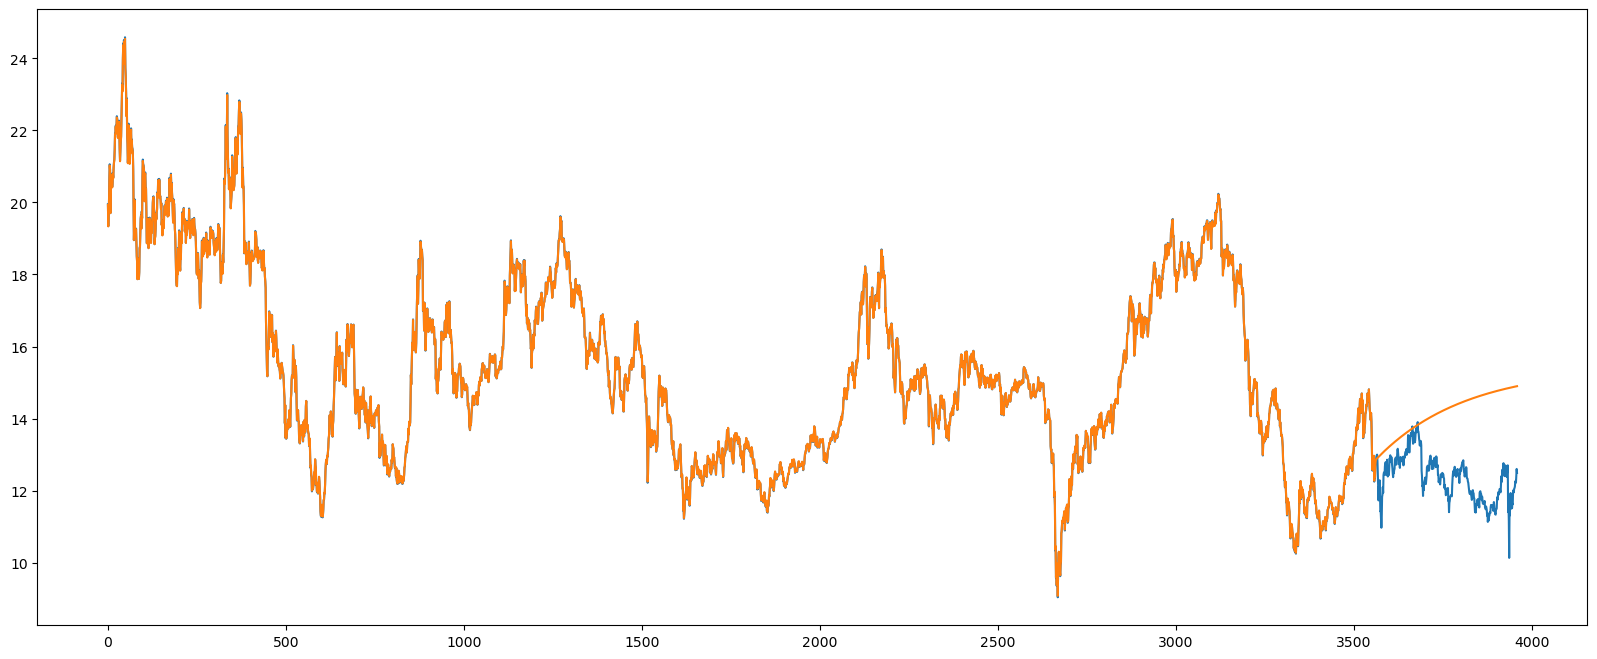

In [17]:
df['Close'].plot()
df['PredictArima'].plot()
plt.show()

In [75]:
df['Close'].max()

258.7355041503906

In [24]:
# 3  SARIMA 
# Fit model with seasonal order (1,1,1,12) - monthly seasonality assumed
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(X_arima_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4))
sarima_fit = sarima_model.fit(disp=False)

In [ ]:
pred = sarima_fit.predict(start=1, end=X_arima.shape[0])
pred.shape, X_arima_train.shape, X_arima_test.shape

((3959,), (3563,), (396,))

In [29]:
r2_score(X_arima_test, pred[-X_arima_test.shape[0]: ])

0.24792757927786968

In [26]:
df['PredictSArima'] = pred

<Axes: >

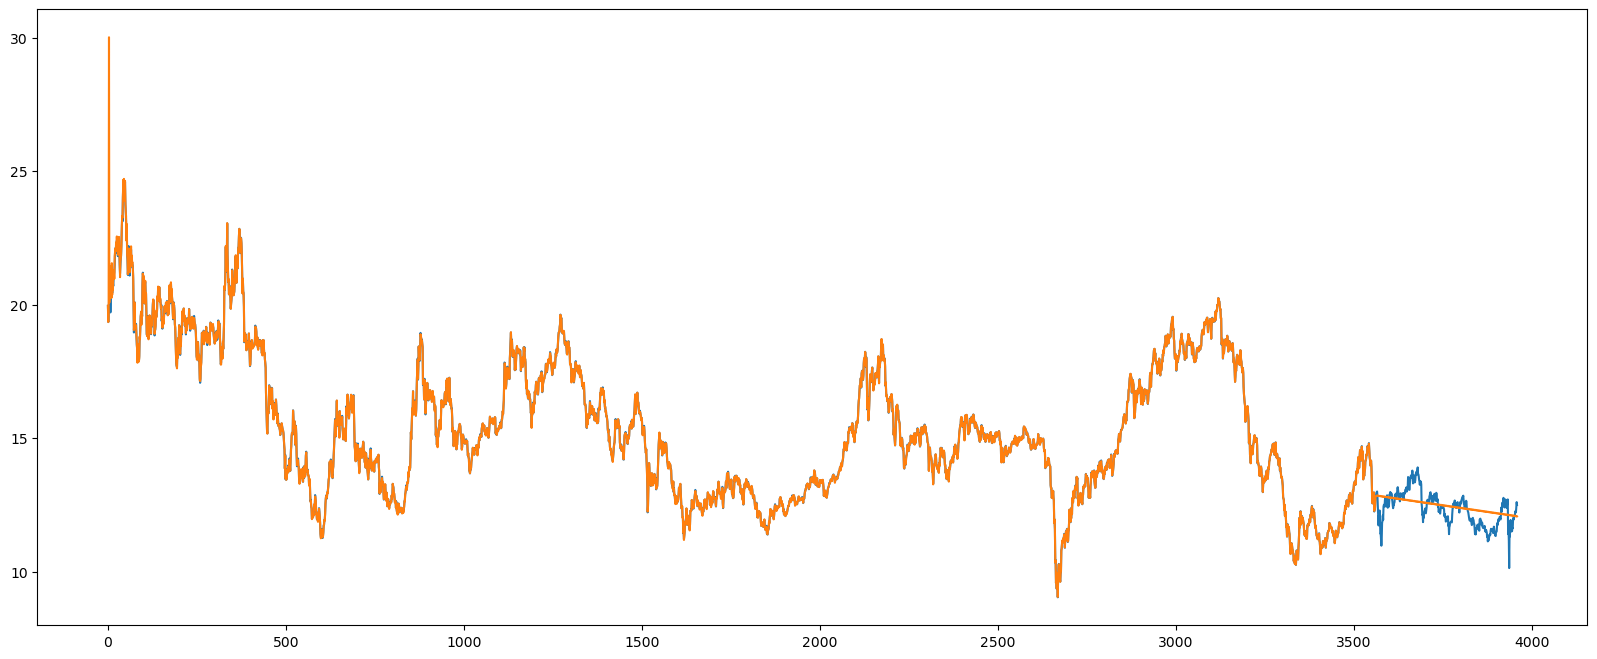

In [27]:
df['Close'].plot()
df['PredictSArima'].plot()

In [2]:
import numpy as np

In [20]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score
p = d = q = range(0, 3)
P = D = Q = range(0, 2)
s = 12  # or 5 if weekly pattern
best_r2 = float('-inf')
best_order = None
best_seasonal_order = None

for order in itertools.product(p, d, q):
    for seasonal_order in itertools.product(P, D, Q):
        #print(order, seasonal_order)
        try:
            model = SARIMAX(X_arima_train,
                            order=order,
                            seasonal_order=(seasonal_order[0], seasonal_order[1], seasonal_order[2], s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)
            forecast = results.predict(start=X_arima_train.shape[0], end=len(X_arima)-1)
            r2 = r2_score(X_arima_test, forecast)
            print(r2)
            if r2 > best_r2:
                best_r2 = r2
                best_order = order
                best_seasonal_order = seasonal_order

        except Exception as e:
            print(e)
            continue

print("Best R²:", best_r2)
print("Best ARIMA order:", best_order)
print("Best Seasonal order:", best_seasonal_order, s)


-398.67747252289723
-390.7102504855001
-0.4244215131047042
-0.6634291855005012
-0.13572041356986864
0.10715414481674801
-0.646156165672817
-0.7494656678963356
-397.74392717921353
-389.7504351132922
-0.41595141299623895
-1.0859381977785758
-0.3816503336526791
0.21635282270859924
-0.9279213940759645
-1.1966824078996656
-396.88268406289825
-389.17561843815923
-0.4161973913488999
-1.6096055225547476
-0.7764782504534808


c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


0.19118993926360373
-1.1695503549280741
-1.5987503969906318
-0.6494681463395275
-0.6974144479665991
-326.40794818307677
0.257952091147734
-0.6915188555327543
-0.7026833176265046
-603.6052466125834
0.26971999984126016
-0.6474754349649208
-0.6973079441856957
-325.19755522438015
0.2276692124709906
-0.6909584688684136
-0.7021597550443053
-604.4536181480092
0.269827454724462
-0.646082898907643
-0.6967456104427183
-317.13545024164193
0.24818094139982239
-0.6905452527276272
-0.7024738800420947
-604.0018697192265
0.26984957775621543
-343.282448792381
-266.97537387652517


c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


-6494542.192983477
-674.7048737941374
-279.28683306048055
-275.6962753707285
-270753.56860057765
-278.54865611131993
0.24873693645334327
0.26479445772089805
-380.8387000396169
-0.49218500736237214
0.2631076785705594
0.2665805798956379
-754.2968162519223
-0.8034251283725753
0.2155941373267971
0.2710595975676403
-379.61546051112765
-0.2626545024601252
0.26330271393163374
0.27506119758672
-755.338543579209
-0.8042904154265247
0.2567080995760487


...

c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


0.22047689038782703
-0.17112901292616467
-8.51405727351283
0.2605784523964556
0.23244567860589715
-0.24242609230965528
-8.126954976307909
-0.6474643059877241
-0.6970533100974652


c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


-325.32395785607423
0.25421450804424695
-0.6905211222774452
-0.7040364413788609
-604.8194112617869
0.26984058120429155


KeyboardInterrupt: 